Installing latest libraries

In [51]:
import os

In [52]:
!pip install -qq fastai ddgs --use-deprecated=legacy-resolver

In [53]:
from ddgs import DDGS
from fastcore.all import *
import time,json

def search_images(keywords,max_images=100, retries=3):
    for i in range(retries):
        try:
            with DDGS() as ddgs:
                results=ddgs.images(keywords,max_results=max_images)
                if not results:
                    return L()
                return L(results).itemgot('image')
        except Exception as e:
            if i== retries - 1:
                print(f"Error searching for {keywords}:{e}")
                return L()
            time.sleep(2**i)
    return L()
    

In [54]:
urls=search_images('dog photos',max_images=1)
urls[0]

'https://images.pexels.com/photos/19024664/pexels-photo-19024664.jpeg?cs=srgb&dl=pexels-csibeman-19024664.jpg&fm=jpg'

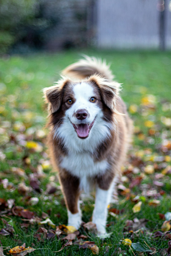

In [55]:
from fastdownload import download_url
dest='dog.jpg'
download_url(urls[0],dest,show_progress=False)
from fastai.vision.all import *
im=Image.open(dest)
im.to_thumb(256,256)

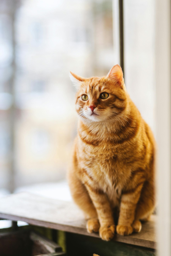

In [56]:
download_url(search_images('cat photos', max_images=1)[0],'cat.jpg',show_progress=False)
Image.open('cat.jpg').to_thumb(256,256)

In [57]:
searches='dog','cat'
path=Path('bird_or_not')
for o in searches:
    dest=(path/o)
    dest.mkdir(exist_ok=True,parents=True)
    download_images(dest,urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o,max_size=400,dest=path/o)

In [58]:
failed=verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

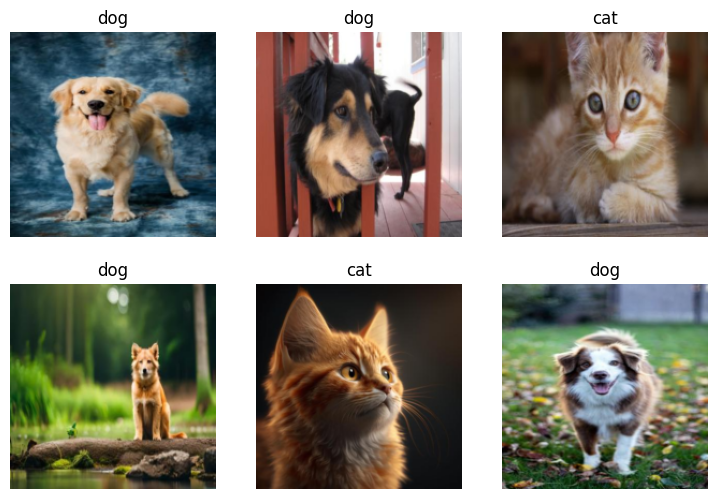

In [59]:
dls=DataBlock(blocks=(ImageBlock,CategoryBlock),get_items=get_image_files,splitter=RandomSplitter(valid_pct=0.2,seed=42),get_y=parent_label,item_tfms=[Resize(192,method='squish')]
             ).dataloaders(path,bs=32)
dls.show_batch(max_n=6)


In [60]:
learn=vision_learner(dls,resnet18,metrics=error_rate)
learn.fine_tune(3)

[W520 19:37:22.243660074 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.268931352 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.284802727 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.310377816 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.311423537 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.324594404 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.326049798 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.326933866 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.327650827 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:37:22.330662815 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:3

epoch,train_loss,valid_loss,error_rate,time
0,0.732821,0.119826,0.043478,00:25


epoch,train_loss,valid_loss,error_rate,time
0,0.073140,0.119851,0.043478,00:27
1,0.052199,0.109419,0.043478,00:26
2,0.040546,0.040403,0.043478,00:25


In [61]:
category,idx,probs=learn.predict(PILImage.create('dog.jpg'))
print(f"This is a: {category}.")
print(f"Probability its a {category}: {probs[idx]:.4f}")
print(f"Probability its a {category}:{ probs}")

[W520 19:39:09.056547521 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:09.124235114 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:09.130394774 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


This is a: dog.
Probability its a dog: 1.0000
Probability its a dog:tensor([1.0581e-07, 1.0000e+00])


In [62]:
learn2=vision_learner(dls,resnet18,metrics=error_rate)
learn2.fine_tune(1)

[W520 19:39:10.380993431 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.387164717 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.389725288 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.392900875 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.395501406 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.396042309 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.400059523 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.401428105 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.403117007 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:10.407051117 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:3

epoch,train_loss,valid_loss,error_rate,time
0,0.739081,0.164994,0.108696,00:19


epoch,train_loss,valid_loss,error_rate,time
0,0.083736,0.049227,0.043478,00:26


In [63]:
category,idx,probs=learn.predict(PILImage.create('dog.jpg'))
print(f"This is a: {category}.")
print(f"Probability its a {category}: {probs[idx]:.4f}")
print(f"Probability its a {category}:{ probs}")

[W520 19:39:58.194616311 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:58.204059597 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:39:58.239100003 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


This is a: dog.
Probability its a dog: 1.0000
Probability its a dog:tensor([1.0581e-07, 1.0000e+00])


In [64]:
learn2=vision_learner(dls,resnet34,metrics=error_rate)
learn2.fine_tune(3)

[W520 19:40:00.215833946 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.216715328 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.220234940 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.221710412 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.223024561 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.233819679 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.235318987 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.269037957 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.272534370 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:40:00.283852725 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:4

epoch,train_loss,valid_loss,error_rate,time
0,0.717226,0.189496,0.108696,00:33


epoch,train_loss,valid_loss,error_rate,time
0,0.096640,0.034475,0.000000,00:43
1,0.056605,0.007157,0.000000,00:45
2,0.039219,0.001146,0.000000,00:46


In [66]:
def is_cat(x):return x[0].isupper()
dls2=ImageDataLoaders.from_name_func(
    path,get_image_files(path),valid_pct=0.2,label_func=is_cat,item_tfms=Resize(128))
learn4=vision_learner(dls2,resnet34,metrics=error_rate)
learn4.fine_tune(1)

[W520 19:44:15.510091731 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.526388602 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.527313166 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.528040101 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.529896055 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.530444958 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.531035560 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.535138406 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.536526039 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:44:15.536924555 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W520 19:4

epoch,train_loss,valid_loss,error_rate,time
0,0.000000,0.000000,0.000000,00:13


epoch,train_loss,valid_loss,error_rate,time
0,0.000000,0.000000,0.000000,00:16


resnet34 has a lower error rate than resnet18 because of being a deeper model taking more time to compute but can be reduced by reducing image resolution (not by alot) while maintaining the low error rate.